# Лабораторная работа №2

**Тема:** алгоритм оппозиционного самообучения для минимизации тестовых функций.

Цель работы — реализовать выбранный эволюционный алгоритм, проверить его на пяти тестовых функциях и сравнить качество поиска глобального минимума по серии независимых запусков.


## Идея алгоритма

В работе используется простой вариант алгоритма оппозиционного самообучения Перепелкина-Круглова.

Основные идеи:

- каждая особь — вещественный вектор `(x, y)`;
- для точки `x` строится оппозиционная точка `x_opp = lower + upper - x`;
- при инициализации и во время работы сравниваются обычные и оппозиционные решения;
- новое решение двигается к лучшей особи, отталкивается от худшей и получает небольшой случайный шум;
- задача решается как минимизация, а приспособленность считается через расстояние до известного теоретического минимума.


In [15]:
from dataclasses import dataclass
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


@dataclass(frozen=True)
class AlgorithmConfig:
    dimensions: int = 2
    population_size: int = 90
    iterations: int = 180
    runs: int = 20
    learning_to_best: float = 0.85
    learning_from_worst: float = 0.35
    start_noise: float = 0.22
    opposition_rate: float = 0.35
    opposition_interval: int = 12
    random_immigrant_rate: float = 0.04
    tolerance: float = 1e-3
    seed: int = 2026


@dataclass(frozen=True)
class TestFunction:
    name: str
    func: object
    bounds: tuple[float, float]
    optimum_value: float
    optimum_point: tuple[float, float]


config = AlgorithmConfig()
notebook_root = Path.cwd()
lab_dir = notebook_root / "EVAL" / "lab_2" if (notebook_root / "EVAL" / "lab_2").exists() else notebook_root
output_dir = lab_dir / "results"
output_dir.mkdir(parents=True, exist_ok=True)


## Тестовые функции

Для простоты все функции берутся в двумерном виде. Это позволяет строить распределение найденных решений на плоскости.


In [16]:
def ackley(points: np.ndarray) -> np.ndarray:
    x = np.atleast_2d(points)
    dimensions = x.shape[1]
    sum_squares = np.sum(x**2, axis=1)
    sum_cosines = np.sum(np.cos(2.0 * np.pi * x), axis=1)
    return -20.0 * np.exp(-0.2 * np.sqrt(sum_squares / dimensions)) - np.exp(sum_cosines / dimensions) + 20.0 + np.e


def rastrigin(points: np.ndarray) -> np.ndarray:
    x = np.atleast_2d(points)
    dimensions = x.shape[1]
    return 10.0 * dimensions + np.sum(x**2 - 10.0 * np.cos(2.0 * np.pi * x), axis=1)


def holder_table(points: np.ndarray) -> np.ndarray:
    x = np.atleast_2d(points)
    a = x[:, 0]
    b = x[:, 1]
    return -np.abs(np.sin(a) * np.cos(b) * np.exp(np.abs(1.0 - np.sqrt(a**2 + b**2) / np.pi)))


def sphere(points: np.ndarray) -> np.ndarray:
    x = np.atleast_2d(points)
    return np.sum(x**2, axis=1)


def rosenbrock(points: np.ndarray) -> np.ndarray:
    x = np.atleast_2d(points)
    return 100.0 * (x[:, 1] - x[:, 0] ** 2) ** 2 + (1.0 - x[:, 0]) ** 2


functions = [
    TestFunction("Ackley", ackley, (-5.0, 5.0), 0.0, (0.0, 0.0)),
    TestFunction("Rastrigin", rastrigin, (-5.12, 5.12), 0.0, (0.0, 0.0)),
    TestFunction("Holder", holder_table, (-10.0, 10.0), -19.2085, (8.055, 9.665)),
    TestFunction("Sphere", sphere, (-5.12, 5.12), 0.0, (0.0, 0.0)),
    TestFunction("Rosenbrock", rosenbrock, (-2.048, 2.048), 0.0, (1.0, 1.0)),
]


## Реализация алгоритма

Ниже находится вся реализация алгоритма: инициализация популяции, оппозиционное обучение, шаг самообучения и сбор статистики.


In [17]:
def calculate_fitness(values: np.ndarray, optimum_value: float) -> np.ndarray:
    gap = np.maximum(values - optimum_value, 0.0)
    return 1.0 / (1.0 + gap)


def calculate_diversity(population: np.ndarray) -> float:
    return float(np.mean(np.std(population, axis=0)))


def make_opposite(population: np.ndarray, bounds: tuple[float, float]) -> np.ndarray:
    lower, upper = bounds
    return lower + upper - population


def select_best(population: np.ndarray, values: np.ndarray, size: int) -> tuple[np.ndarray, np.ndarray]:
    order = np.argsort(values)[:size]
    return population[order].copy(), values[order].copy()


def initialize_population(task: TestFunction, rng: np.random.Generator, cfg: AlgorithmConfig) -> tuple[np.ndarray, np.ndarray]:
    lower, upper = task.bounds
    population = rng.uniform(lower, upper, size=(cfg.population_size, cfg.dimensions))
    opposite = make_opposite(population, task.bounds)
    combined = np.vstack([population, opposite])
    values = task.func(combined)
    return select_best(combined, values, cfg.population_size)


def run_algorithm(task: TestFunction, seed: int, cfg: AlgorithmConfig) -> dict[str, object]:
    rng = np.random.default_rng(seed)
    lower, upper = task.bounds
    population, values = initialize_population(task, rng, cfg)

    best_history = []
    avg_fitness_history = []
    max_fitness_history = []
    diversity_history = []
    convergence_iteration = cfg.iterations

    for iteration in range(1, cfg.iterations + 1):
        best_index = int(np.argmin(values))
        worst_index = int(np.argmax(values))
        best = population[best_index]
        worst = population[worst_index]

        progress = iteration / cfg.iterations
        noise_sigma = cfg.start_noise * (1.0 - progress)
        candidates = []

        for current in population:
            step_to_best = cfg.learning_to_best * rng.random(cfg.dimensions) * (best - current)
            step_from_worst = cfg.learning_from_worst * rng.random(cfg.dimensions) * (current - worst)
            noise = noise_sigma * rng.normal(size=cfg.dimensions)
            candidate = np.clip(current + step_to_best + step_from_worst + noise, lower, upper)

            if rng.random() < cfg.opposition_rate:
                opposite_candidate = np.clip(make_opposite(candidate.reshape(1, -1), task.bounds)[0], lower, upper)
                if task.func(opposite_candidate.reshape(1, -1))[0] < task.func(candidate.reshape(1, -1))[0]:
                    candidate = opposite_candidate

            candidates.append(candidate)

        candidates = np.array(candidates)
        combined = np.vstack([population, candidates])

        if iteration % cfg.opposition_interval == 0:
            combined = np.vstack([combined, make_opposite(combined, task.bounds)])

        immigrant_count = max(1, int(cfg.population_size * cfg.random_immigrant_rate))
        immigrants = rng.uniform(lower, upper, size=(immigrant_count, cfg.dimensions))
        combined = np.vstack([combined, immigrants])

        combined_values = task.func(combined)
        population, values = select_best(combined, combined_values, cfg.population_size)

        fitness = calculate_fitness(values, task.optimum_value)
        best_value = float(values[0])
        best_history.append(best_value)
        avg_fitness_history.append(float(np.mean(fitness)))
        max_fitness_history.append(float(np.max(fitness)))
        diversity_history.append(calculate_diversity(population))

        if convergence_iteration == cfg.iterations and abs(best_value - task.optimum_value) <= cfg.tolerance:
            convergence_iteration = iteration

    return {
        "task": task.name,
        "seed": seed,
        "best_point": population[0].copy(),
        "best_value": float(values[0]),
        "final_population": population.copy(),
        "final_values": values.copy(),
        "best_history": np.array(best_history),
        "avg_fitness_history": np.array(avg_fitness_history),
        "max_fitness_history": np.array(max_fitness_history),
        "diversity_history": np.array(diversity_history),
        "convergence_iteration": convergence_iteration,
    }


## Запуск экспериментов

Для каждой функции выполняется 20 независимых запусков. Это нужно, чтобы оценить не только лучший результат, но и устойчивость алгоритма.


In [18]:
all_results: dict[str, list[dict[str, object]]] = {}
summary_rows = []

for task_index, task in enumerate(functions):
    task_results = []
    task_start = perf_counter()

    for run_index in range(config.runs):
        seed = config.seed + task_index * 1000 + run_index
        run_start = perf_counter()
        result = run_algorithm(task, seed, config)
        result["time_seconds"] = perf_counter() - run_start
        task_results.append(result)

    all_results[task.name] = task_results
    values = np.array([item["best_value"] for item in task_results])
    errors = np.abs(values - task.optimum_value)
    relative_errors = errors / max(1.0, abs(task.optimum_value))
    iterations = np.array([item["convergence_iteration"] for item in task_results])
    times = np.array([item["time_seconds"] for item in task_results])
    best_result = min(task_results, key=lambda item: item["best_value"])
    best_point = tuple(float(x) for x in np.round(best_result["best_point"], 6))

    summary_rows.append({
        "Функция": task.name,
        "Лучшее значение": float(values.min()),
        "Среднее значение": float(values.mean()),
        "Худшее значение": float(values.max()),
        "Стандартное отклонение": float(values.std()),
        "Средняя ошибка": float(errors.mean()),
        "Средняя относительная ошибка": float(relative_errors.mean()),
        "Средняя итерация сходимости": float(iterations.mean()),
        "Среднее время, с": float(times.mean()),
        "Лучшая точка": best_point,
        "Время всех запусков, с": float(perf_counter() - task_start),
    })

summary = pd.DataFrame(summary_rows)
summary


,Функция,Лучшее значение,Среднее значение,Худшее значение,Стандартное отклонение,Средняя ошибка,Средняя относительная ошибка,Средняя итерация сходимости,"Среднее время, с",Лучшая точка,"Время всех запусков, с"
0,Ackley,3.628554e-05,2.041022e-04,4.314406e-04,1.222726e-04,2.041022e-04,2.041022e-04,166.00,0.348381,"(-1e-05, -7e-06)",6.967749
1,Rastrigin,3.235051e-08,9.692412e-07,2.577117e-06,7.106237e-07,9.692412e-07,9.692412e-07,105.05,0.282431,"(7e-06, -1.1e-05)",5.648740
2,Holder,-1.920850e+01,-1.920846e+01,-1.920824e+01,5.857832e-05,3.656123e-05,1.903388e-06,53.40,0.273685,"(8.055072, 9.664682)",5.473807
3,Sphere,2.550914e-11,6.105165e-09,1.769385e-08,4.653477e-09,6.105165e-09,6.105165e-09,4.85,0.234015,"(-1e-06, 5e-06)",4.680408
4,Rosenbrock,4.539801e-09,6.890141e-07,1.873037e-06,5.549468e-07,6.890141e-07,6.890141e-07,20.35,0.242750,"(0.999962, 0.99993)",4.855107


## Визуализация результатов

Для каждой функции строятся три графика: сходимость, финальное распределение решений и разнообразие популяции. Также строится общий boxplot по значениям целевой функции после 20 запусков.


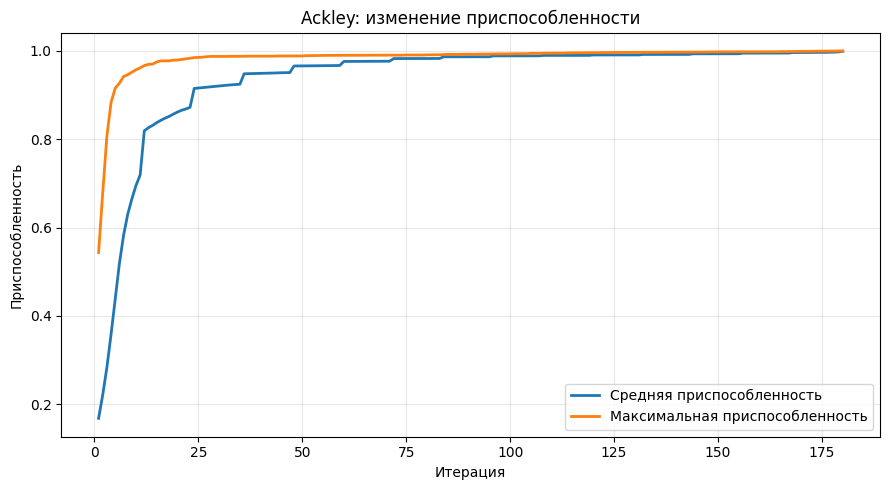

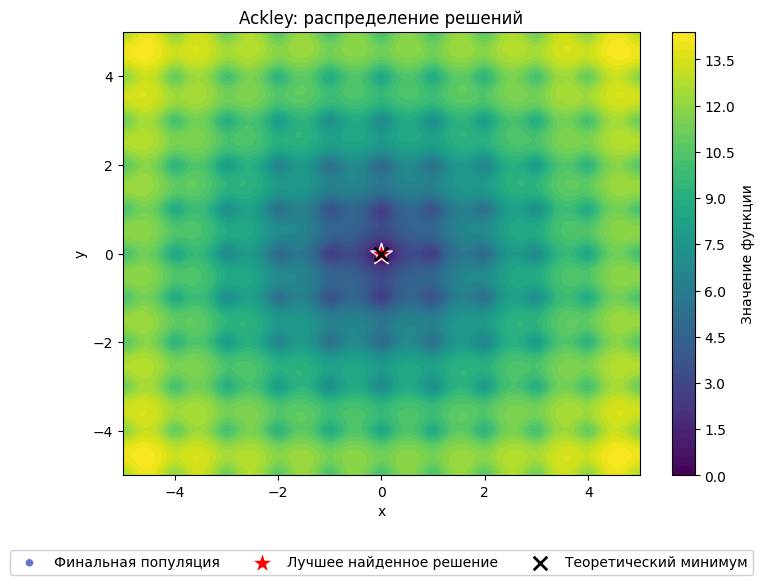

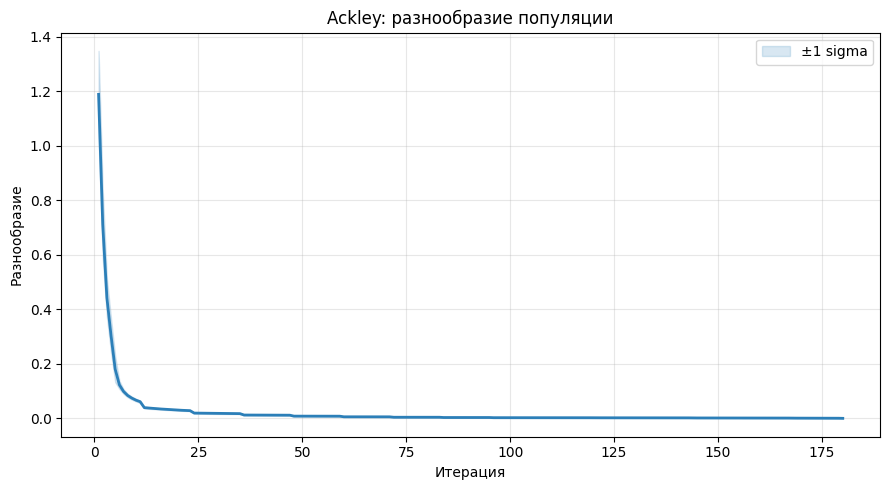

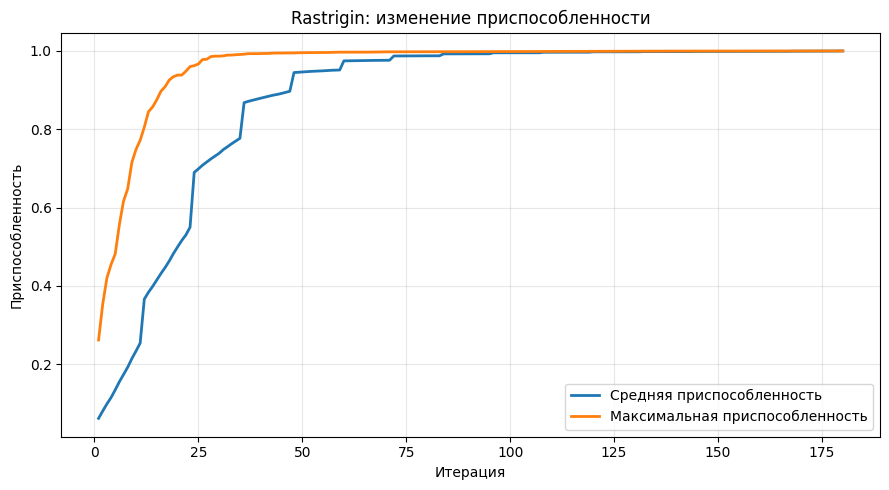

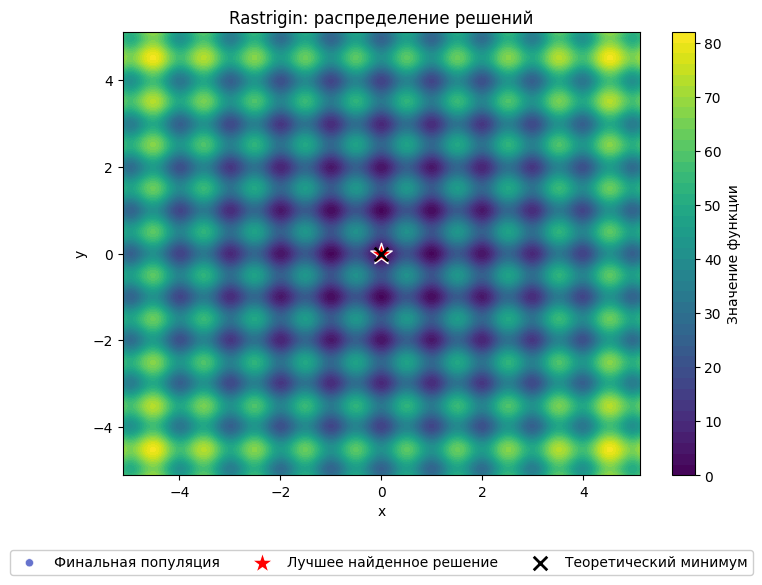

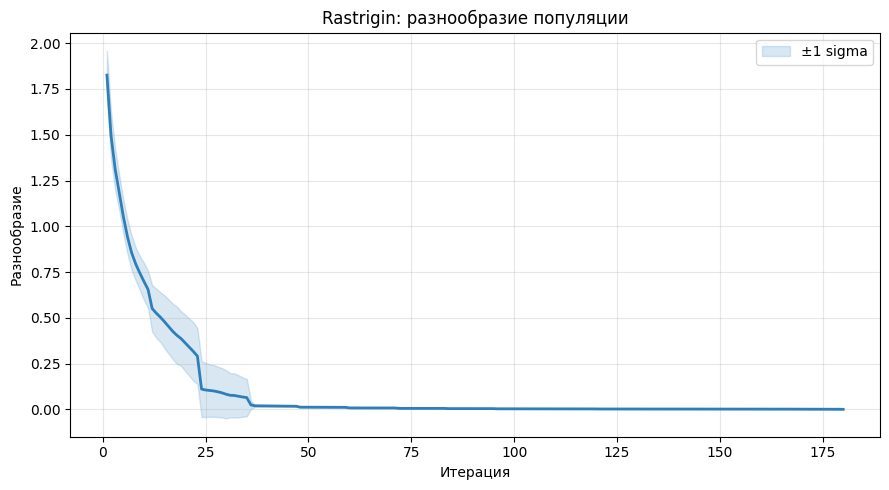

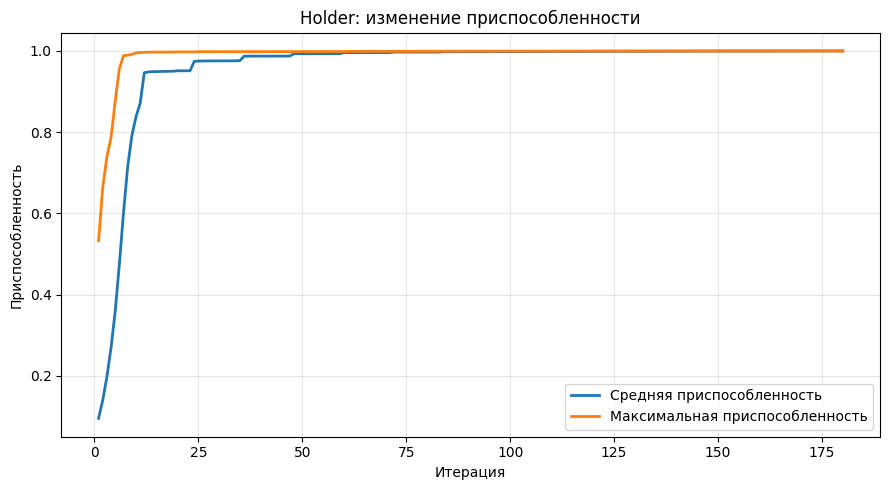

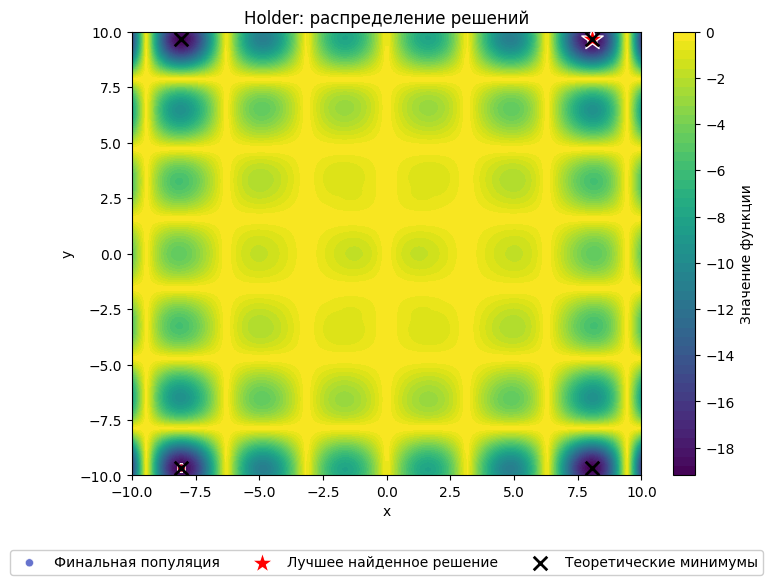

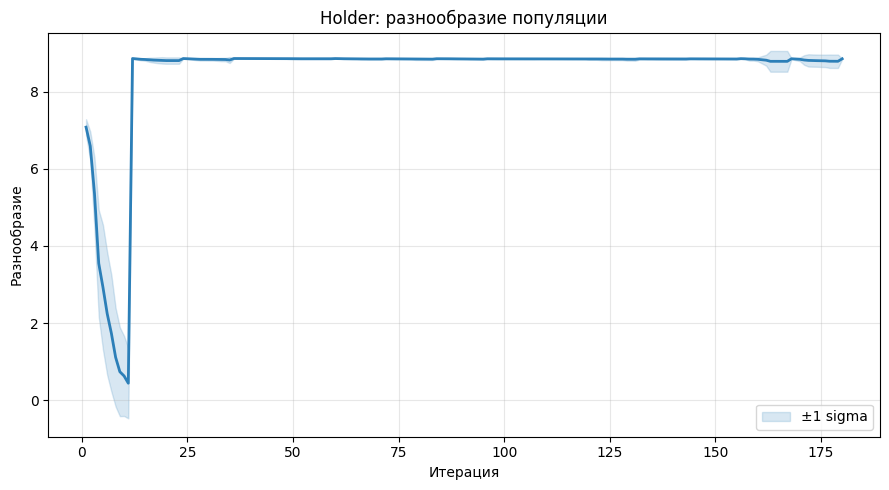

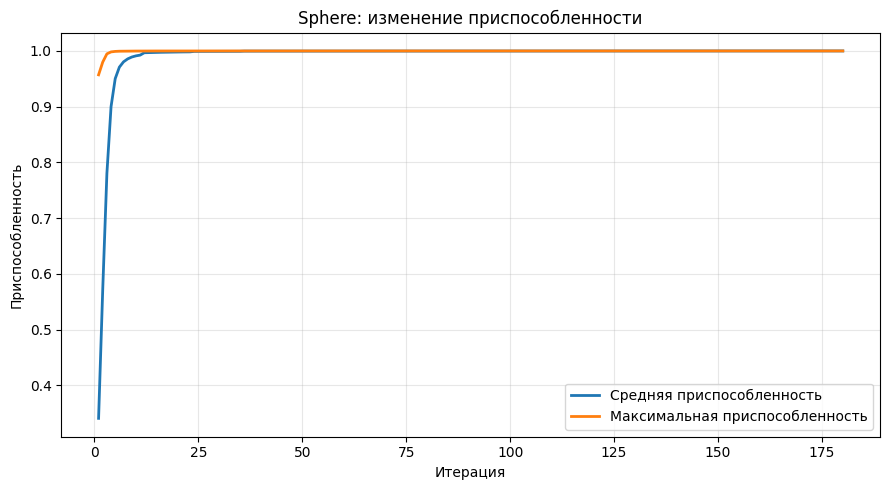

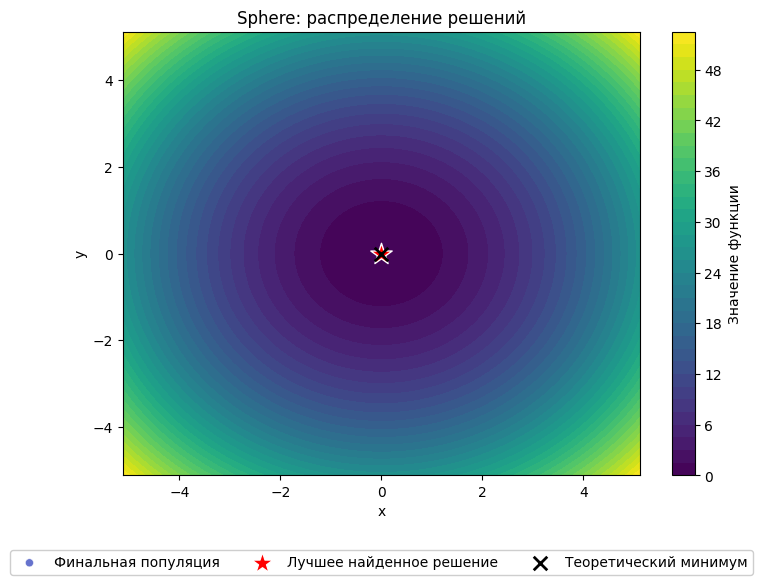

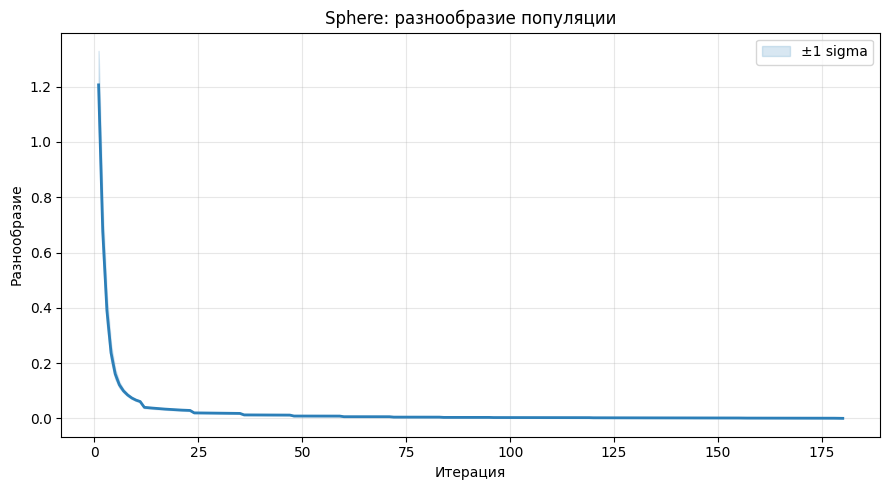

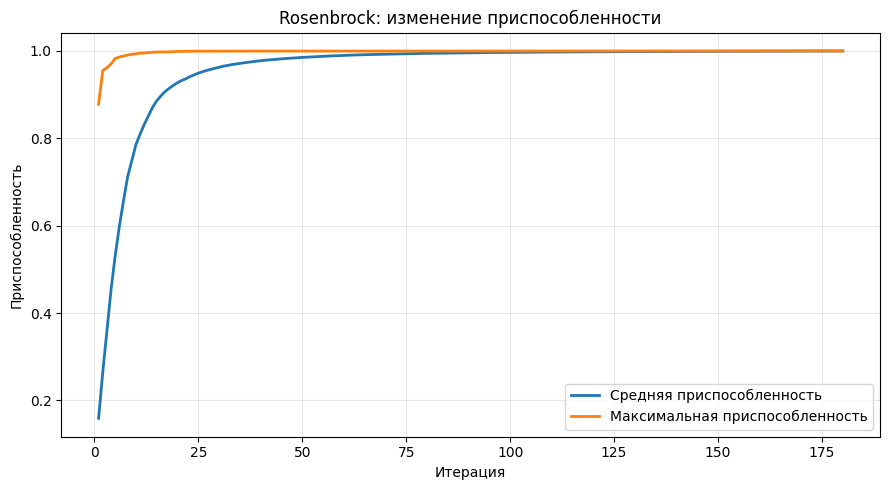

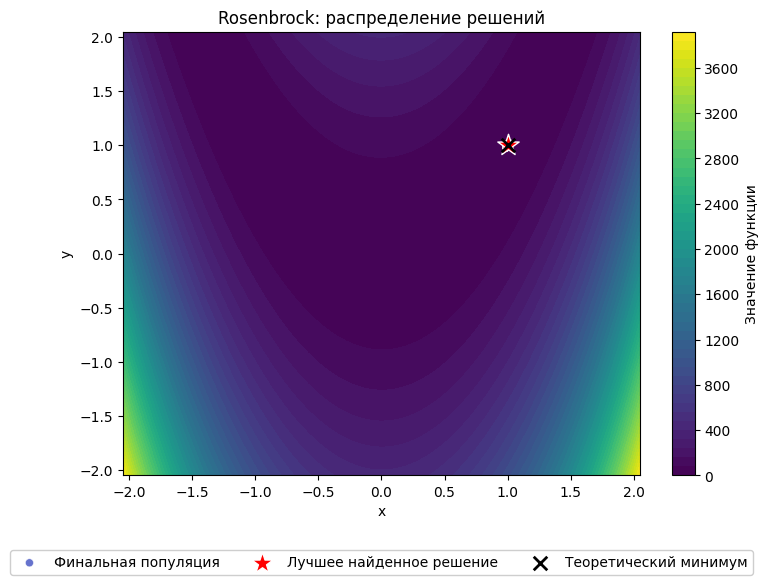

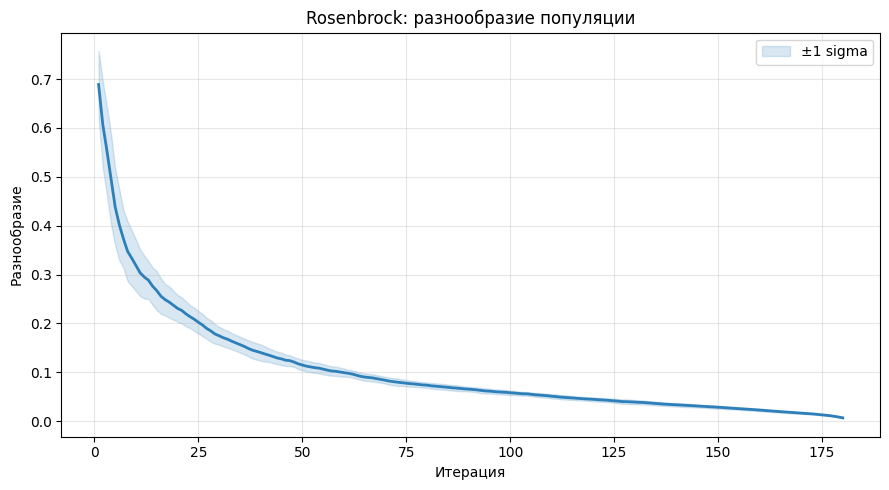

In [19]:
def make_grid(task: TestFunction, points_count: int = 180) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    lower, upper = task.bounds
    grid = np.linspace(lower, upper, points_count)
    x_grid, y_grid = np.meshgrid(grid, grid)
    points = np.column_stack([x_grid.ravel(), y_grid.ravel()])
    z_grid = task.func(points).reshape(x_grid.shape)
    return x_grid, y_grid, z_grid


def plot_task_results(task: TestFunction, results: list[dict[str, object]]) -> None:
    iterations = np.arange(1, config.iterations + 1)
    avg_fitness = np.array([item["avg_fitness_history"] for item in results])
    max_fitness = np.array([item["max_fitness_history"] for item in results])
    diversity = np.array([item["diversity_history"] for item in results])
    best_run = min(results, key=lambda item: item["best_value"])

    plt.figure(figsize=(9, 5))
    plt.plot(iterations, avg_fitness.mean(axis=0), label="Средняя приспособленность", linewidth=2)
    plt.plot(iterations, max_fitness.mean(axis=0), label="Максимальная приспособленность", linewidth=2)
    plt.xlabel("Итерация")
    plt.ylabel("Приспособленность")
    plt.title(f"{task.name}: изменение приспособленности")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / f"{task.name.lower()}_fitness.png", dpi=160)
    plt.show()

    x_grid, y_grid, z_grid = make_grid(task)
    plt.figure(figsize=(8, 6))
    contour = plt.contourf(x_grid, y_grid, z_grid, levels=50, cmap="viridis")
    plt.colorbar(contour, label="Значение функции")
    population = best_run["final_population"]
    values = best_run["final_values"]
    plt.scatter(
        population[:, 0],
        population[:, 1],
        c=values,
        s=34,
        cmap="coolwarm",
        edgecolor="white",
        linewidth=0.45,
        alpha=0.78,
        label="Финальная популяция",
    )
    best_point = best_run["best_point"]
    plt.scatter(
        [best_point[0]],
        [best_point[1]],
        c="red",
        marker="*",
        s=260,
        edgecolor="white",
        linewidth=1.0,
        label="Лучшее найденное решение",
        zorder=6,
    )
    if task.name == "Holder":
        optimum_points = np.array([
            [8.055, 9.665],
            [-8.055, 9.665],
            [8.055, -9.665],
            [-8.055, -9.665],
        ])
        plt.scatter(
            optimum_points[:, 0],
            optimum_points[:, 1],
            c="black",
            marker="x",
            s=95,
            linewidth=2.0,
            label="Теоретические минимумы",
            zorder=7,
        )
    else:
        plt.scatter([task.optimum_point[0]], [task.optimum_point[1]], c="black", marker="x", s=95, linewidth=2.0, label="Теоретический минимум", zorder=7)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"{task.name}: распределение решений")
    plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.24), ncol=3, framealpha=0.95)
    plt.tight_layout()
    plt.savefig(output_dir / f"{task.name.lower()}_population.png", dpi=160, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 5))
    mean_diversity = diversity.mean(axis=0)
    std_diversity = diversity.std(axis=0)
    plt.plot(iterations, mean_diversity, color="#2c7fb8", linewidth=2)
    plt.fill_between(iterations, mean_diversity - std_diversity, mean_diversity + std_diversity, color="#2c7fb8", alpha=0.18, label="±1 sigma")
    plt.xlabel("Итерация")
    plt.ylabel("Разнообразие")
    plt.title(f"{task.name}: разнообразие популяции")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / f"{task.name.lower()}_diversity.png", dpi=160)
    plt.show()


for task in functions:
    plot_task_results(task, all_results[task.name])


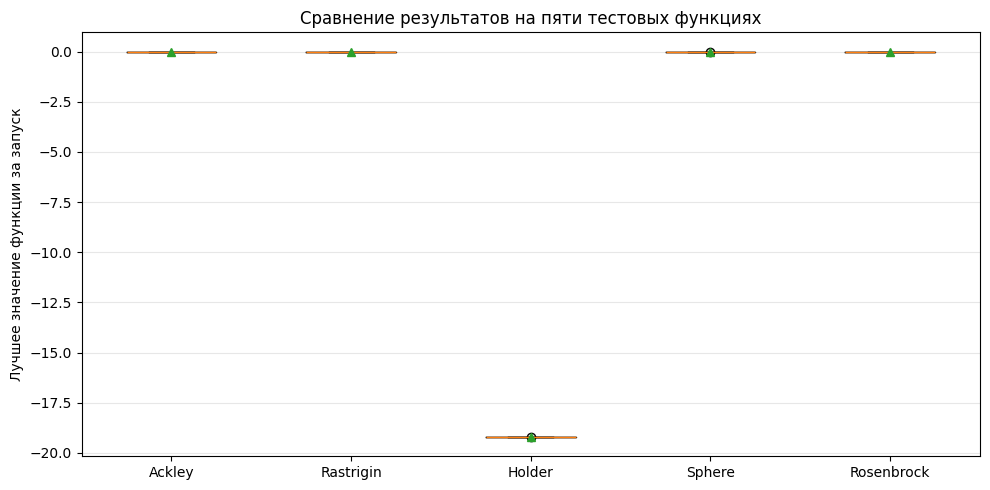

,Функция,Лучшее значение,Среднее значение,Худшее значение,Стандартное отклонение,Средняя ошибка,Средняя относительная ошибка,Средняя итерация сходимости,"Среднее время, с",Лучшая точка,"Время всех запусков, с"
0,Ackley,3.628554e-05,2.041022e-04,4.314406e-04,1.222726e-04,2.041022e-04,2.041022e-04,166.00,0.348381,"(-1e-05, -7e-06)",6.967749
1,Rastrigin,3.235051e-08,9.692412e-07,2.577117e-06,7.106237e-07,9.692412e-07,9.692412e-07,105.05,0.282431,"(7e-06, -1.1e-05)",5.648740
2,Holder,-1.920850e+01,-1.920846e+01,-1.920824e+01,5.857832e-05,3.656123e-05,1.903388e-06,53.40,0.273685,"(8.055072, 9.664682)",5.473807
3,Sphere,2.550914e-11,6.105165e-09,1.769385e-08,4.653477e-09,6.105165e-09,6.105165e-09,4.85,0.234015,"(-1e-06, 5e-06)",4.680408
4,Rosenbrock,4.539801e-09,6.890141e-07,1.873037e-06,5.549468e-07,6.890141e-07,6.890141e-07,20.35,0.242750,"(0.999962, 0.99993)",4.855107


In [20]:
boxplot_data = [np.array([item["best_value"] for item in all_results[task.name]]) for task in functions]
labels = [task.name for task in functions]

plt.figure(figsize=(10, 5))
plt.boxplot(boxplot_data, tick_labels=labels, showmeans=True)
plt.ylabel("Лучшее значение функции за запуск")
plt.title("Сравнение результатов на пяти тестовых функциях")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "comparison_boxplot.png", dpi=160)
plt.show()

summary.to_csv(output_dir / "summary.csv", index=False, encoding="utf-8-sig")
summary


## Сохранение краткого отчета

В папку `results/` сохраняются графики, таблица `summary.csv` и текстовый файл `summary.txt` с основными числами.


In [21]:
summary_lines = [
    "Лабораторная работа N2",
    "Тема: алгоритм оппозиционного самообучения для тестовых функций",
    "",
    f"Размер популяции: {config.population_size}",
    f"Число итераций: {config.iterations}",
    f"Число запусков на функцию: {config.runs}",
    "",
]

for _, row in summary.iterrows():
    summary_lines.extend([
        f"Функция: {row['Функция']}",
        f"  лучшее значение: {row['Лучшее значение']:.12g}",
        f"  среднее значение: {row['Среднее значение']:.12g}",
        f"  худшее значение: {row['Худшее значение']:.12g}",
        f"  средняя ошибка: {row['Средняя ошибка']:.12g}",
        f"  средняя относительная ошибка: {row['Средняя относительная ошибка']:.12g}",
        f"  средняя итерация сходимости: {row['Средняя итерация сходимости']:.2f}",
        f"  среднее время, с: {row['Среднее время, с']:.4f}",
        f"  лучшая точка: {row['Лучшая точка']}",
        "",
    ])

(output_dir / "summary.txt").write_text("\n".join(summary_lines), encoding="utf-8")
print("Результаты сохранены в", output_dir)


Результаты сохранены в c:\Users\motyn\Desktop\repositories\_OMSTU\EVAL\lab_2\results


## Анализ результатов

Алгоритм лучше всего справляется с функцией Sphere, потому что она гладкая, выпуклая и имеет один простой глобальный минимум. На Ackley и Rastrigin поиск сложнее из-за большого числа локальных областей, но оппозиционные точки помогают быстрее проверять симметричные части пространства поиска.

Функция Holder является мультимодальной и имеет несколько равноценных минимумов, поэтому результаты между запусками могут заметно отличаться по координатам, но не обязательно по значению функции. Rosenbrock обычно оказывается самой неприятной для простых эволюционных алгоритмов: минимум лежит в узкой изогнутой долине, поэтому популяция может быстро приблизиться к хорошей области, но медленно уточнять координаты.

Разнообразие популяции постепенно уменьшается: сначала алгоритм исследует область поиска, затем отбор лучших и самообучение стягивают популяцию к найденному минимуму. Случайные иммигранты и периодическое оппозиционное обучение нужны для того, чтобы популяция не схлопывалась слишком рано.


## Вывод

В лабораторной работе реализован алгоритм оппозиционного самообучения и проведена серия экспериментов на пяти тестовых функциях. Для каждой функции получены графики приспособленности, распределения решений и разнообразия популяции, а также сводная таблица метрик по 20 независимым запускам.
